In [ ]:
# Import the required dependencies
import numpy as np 
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

## Read in data

Download the data, view the raw data and read it in.

In [2]:
# Locate the file
file_name = "apartments_small.csv"

# In the data, the category 'pets_allowed' has the value "None",
# or a comma-separated list of pets allowed (eg "Cats, Dogs")

# By default, pandas has a built-in list of words it considers missing data (NaN):
# NaN, NULL, N/A, n/a, and often None

# We need to tell pandas to consider "null" as missing data, but not "None"

# Declare the separator is ';' (, is default but data here is different)
# Disable default na values and explicitly label 'null' as missing data
data = pd.read_csv(file_name, sep=';',keep_default_na=False, na_values='null')

# This displays the first 5 rows of the data (sanity check)
data.head()

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
8623,5668610646,housing/rent/apartment,Three BR 128 Magazine Street,"This unit is located at 128 Magazine Street, D...","Dishwasher,Refrigerator",2.0,3,USD,No,Thumbnail,...,"$1,149",Monthly,1340,128 Magazine St,Dallas,GA,33.9217,-84.8634,RentLingo,1577358343
3516,5668614464,housing/rent/apartment,One BR 11775 Wadsworth Blvd,"This unit is located at 11775 Wadsworth Blvd, ...","Cable or Satellite,Clubhouse,Dishwasher,Firepl...",1.0,1,USD,No,Thumbnail,...,"$1,406",Monthly,704,11775 Wadsworth Boulevard,Broomfield,CO,39.9156,-105.0876,RentLingo,1577358607
5285,5509045112,housing/rent/apartment,One BR Apartment in Quiet Building - Cincinnat...,"Welcome in Forest Park, Ohio! community was de...","Parking,Patio/Deck,Pool",1.0,1,USD,No,Yes,...,$850,Monthly,831,NaN,Cincinnati,OH,39.2858,-84.5220,RentDigs.com,1568769865
5879,5668617994,housing/rent/apartment,Two BR 101 Shamrock Circle,"This unit is located at 101 Shamrock Circle, P...","Cable or Satellite,Clubhouse,Dishwasher,Garbag...",2.0,2,USD,No,Thumbnail,...,"$1,199",Monthly,895,101 Shamrock Cir,Pendleton,IN,39.9925,-85.7729,RentLingo,1577358826
9377,5668643253,housing/rent/apartment,Three BR 1446 Eberhart,"This unit is located at 1446 Eberhart, Edwards...",NaN,2.0,3,USD,No,Thumbnail,...,"$1,400",Monthly,1776,1446 Eberhart,Edwardsville,IL,38.8098,-89.9522,RentLingo,1577360557


## Data Cleaning

Read the [variable information](https://openflights.org/data.php) on the website and look at the data in the columns to get an understanding of what each variable represents.

In [12]:
# data.dtypes returns a series which Jupyter displays as simple text
# Converting to a DataFrame makes it easier to read in Jupyter (not essential)

data.dtypes.to_frame(name='Data Type')

,Data Type
id,int64
category,str
title,str
body,str
amenities,str
bathrooms,float64
bedrooms,int64
currency,str
fee,str
has_photo,str


Convert column types in the data to the correct types if they are not what you'd expect.

In [7]:
# List out the columns which are categories to change their type from str to category
category_columns = ["currency", "fee", "has_photo", "price_type", "source"]

# Convert the category columns to the 'category' data type in one go
data[category_columns] = data[category_columns].astype('category')

data.dtypes.to_frame(name='Updated data Type')

,Updated data Type
id,int64
category,str
title,str
body,str
amenities,str
bathrooms,float64
bedrooms,int64
currency,category
fee,category
has_photo,category


#### Missing Values

Check for missing values 

In [9]:
# data.isna() returns a 1 (true) or 0 (false) for each value in the dataframe
# depending on whether it is null or not

# the sum function takes axis=0 or axis=1
# axis=0 sums down the columns (ie gives the total number of missing values in each column)
# axis=1 sums across the rows (ie gives the total number of missing values in each row)

# to_frame is only used for visual purposes (not essential)
data.isna().sum(axis=0).to_frame(name='# Missing values')

,# Missing values
id,0
category,0
title,0
body,0
amenities,357
bathrooms,2
bedrooms,0
currency,0
fee,0
has_photo,0


* Which rows would you drop?
* Which features would you drop?
* Would you replace data for any features?

## Data Exploration

### Consider the attributes

For each feature we need to know

* Name, description, what does it mean?
* Type, categorical (ordered?), numerical (int/float), text etc.
* Missing values.
* Noisiness and type of noise.
* Usefulness.
* Distribution
* Is it a unique identifier?

You can find some of this information on the webpage. The name is often different to the column heading, the column heading is easily usable in code, the name easily understandable by humans. You would typically use the name to label graphs or tables that are output for people other than yourself to read. Information about the variables might also give you an idea of usefulness. 

#### Look for unique identifiers

How many different values are there for each each column, 
this can help identifier unique identifiers which we may want to exclude.
If it is a unique identifier, is there any data encoded within the identifier 
that might be useful, e.g. date, order, location.

In [19]:
data.nunique().to_frame("# of unique values")

# From this we can see that id and body have the same number of unique 
# values as there are rows in the data and title has nearly the same.
# These are unique identifiers.
# Many of the numeric columns also have nearly unique values
# this doesn't indicate they are unique identifiers

,# of unique values
id,1000
category,1
title,978
body,1000
amenities,400
bathrooms,9
bedrooms,7
currency,1
fee,1
has_photo,3


### Distribution

For each feature plot the distribution.

#### Continuous features

Ask your self what sort of distribution is it?

* uniform,
* symmetrical about a centre point, 
* an initial peak then falls?
* is it a narrow or wide spread of data? 
* Are there lots of outliers? 
* Is it bounded, e.g. all values are above 0, or within a certain range?

Does it fall into obvious groups, might it be better to split this data into categories instead?

Would you replace missing data with mean or median. 

In [ ]:
# The long tails indicate it would be better to replace missing values with median 
# rather than mean. The median will be closer to the bulk of the data, 
# the mean will be further into the tail
# maybe it would be best to replace bed and bathrooms with most common values

#### Categorical features

* Are the categories approximately balanced, 
* or are there many more of some categories.

Bathrooms and bedrooms could be plotted as either numeric or as categories

Based on your exploration so far how would you deal with the missing data?

In [ ]:
# You could drop the columns with only one value
# You could replace with the most common values
# For pets allowed and photo, 
# it might be best to use the No or None as the obvious default.

### Order

Sometimes datasets are saved in a particular order. 
It is a good idea to plot features against order in the dataset to see if this is the case. Often we want data arranged randomly, so it is important to know if there is an underlying order.

In [ ]:
# There is no obvious pattern compared to the order of the data for price
sns.scatterplot(x=list(range(1000)), y=data['price'])
# You should also check the other variables

### Look for relationships with response

Plot each attribute against the response, 
this will give you an idea if there is any pattern or relationship 
between the variable and the response.

#### Continuous vs Continuous

* Is there any pattern in the data?
  - Is it strong or weak
  - Is the pattern linear or non linear
  - Is it positive or negative

In [ ]:
# REPEAT FOR EVERY NUMERICAL VARIABLE
# Numerical variables:
# price, square_feet, latitude, longitude, time

sns.scatterplot(x=data['square_feet'], y=data['price'])
# price vs square feet has a strong, linear, positive relationship
# but it is noisy

Geographical plot

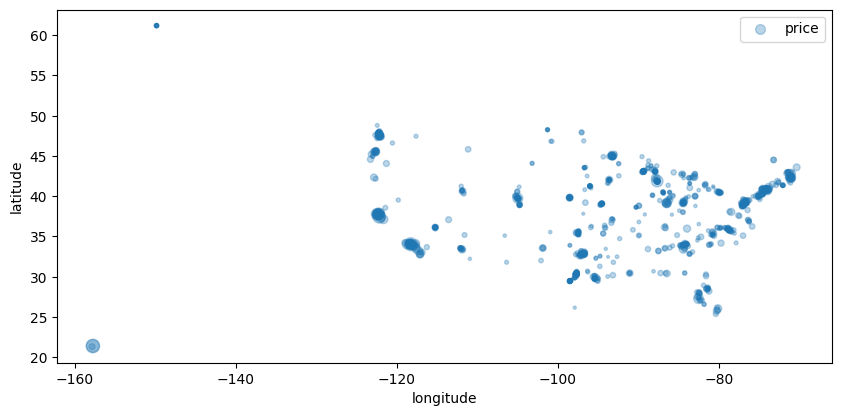

In [53]:
plot = data.plot(kind="scatter", 
    x="longitude", y="latitude", alpha=0.3,
    s=data["price"]/100,
    label="price", figsize=(10,7), sharex=False)
plot.set_aspect('equal')

#### Continuous vs Feature

* Is there a difference between groups
  - look at centre?
  - look at range?

<Axes: xlabel='bedrooms', ylabel='price'>

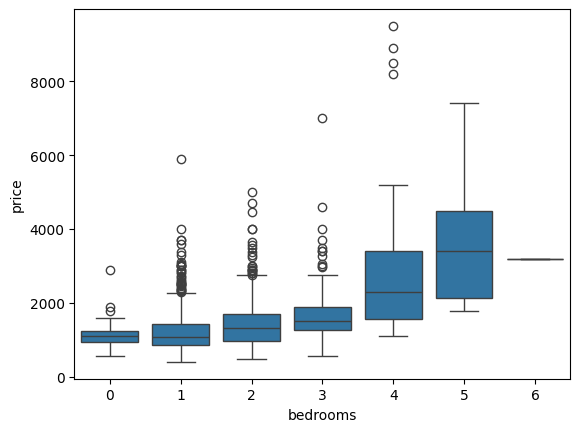

In [54]:
sns.boxplot(x=data['bedrooms'], y=data['price'])
# clear rising trend

### Look for relationships with other variables

Plot each feature against other features. If there is a very strong relationship between two features you may choose to exclude one or the other from the model.

<Axes: xlabel='latitude', ylabel='square_feet'>

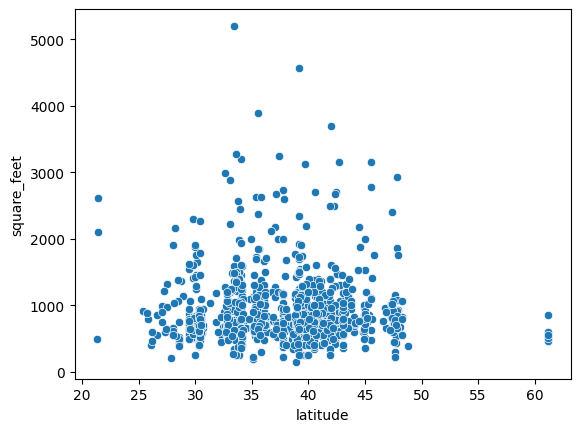

In [60]:
# Maybe some pattern in latitude less visible in longitude
sns.scatterplot(x=data['latitude'], y=data['square_feet'])

#### Feature vs Feature

Does a category occur more often with some categories than others

In [66]:
# some relationship between no of bedrooms and bathrooms
pd.crosstab(data['bedrooms'], data['bathrooms'])
# check other factor variables in same manner

bathrooms,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0
bedrooms,,,,,,,,,
0,19,0,0,0,0,0,0,0,0
1,496,4,1,0,0,0,0,0,0
2,144,25,135,9,1,0,0,0,0
3,22,3,65,7,12,1,1,0,0
4,2,0,19,5,7,3,5,0,0
5,1,1,2,1,2,2,0,2,0
6,0,0,0,0,0,0,0,0,1


### Check correlations

In [77]:
correlations = data.corr(numeric_only=True)
correlations

,id,bathrooms,bedrooms,price,square_feet,latitude,longitude,time
id,1.000000,-0.031630,0.054328,0.012756,0.025767,-0.078466,-0.191686,0.999826
bathrooms,-0.031630,1.000000,0.733833,0.509812,0.799611,-0.061404,-0.031226,-0.032924
bedrooms,0.054328,0.733833,1.000000,0.419315,0.761180,-0.013428,0.019321,0.052862
price,0.012756,0.509812,0.419315,1.000000,0.510787,0.003370,-0.257913,0.012151
square_feet,0.025767,0.799611,0.761180,0.510787,1.000000,0.010508,0.003751,0.024142
latitude,-0.078466,-0.061404,-0.013428,0.003370,0.010508,1.000000,-0.112729,-0.079477
longitude,-0.191686,-0.031226,0.019321,-0.257913,0.003751,-0.112729,1.000000,-0.192771
time,0.999826,-0.032924,0.052862,0.012151,0.024142,-0.079477,-0.192771,1.000000


## More data cleaning

Now we have learned more about the data we can make some more decisions about the best ways to clean the data.

### Deal with the missing data

* Remove rows with lots of missing data
* Remove columns with lots of missing data
* Fill in values for remaining missing data

In [ ]:
data['pets_allowed'].unique()

In [ ]:
# drop rows that have lots of missing data, doesn't apply in this case

# drop columns that have only one value
data = data.drop(columns=["currency", "fee", "price_type"])

# We probably want to keep both the rows and columns but need to fill in the data
# Lets use None as the default for pets allowed if data missing
data['pets_allowed'] = np.where(data['pets_allowed'].isnull, 
                          "None", data['pets_allowed'])

# For bathrooms lets replace with most common value 1
data['bathrooms'] = np.where(data['bathrooms'], 1.0, data['bathrooms'])

# For the small number of city, state missing data 
# we could find the missing info from the body.
# City and state are likely to have large effects,
# imputing the mode only has a 1 in 50 chance of being right for the state
# and even less for the city

# It might be easier to just drop the missing rows in this case
data = data[data['state'].notnull()]

## Feature selection

Based on your exploration above if you could only select 5 features what would they be?
Similarly what features would you be most likely to drop from the model?

In [ ]:
# Feature selection is more art than science. 
# I would keep: bedrooms, bathrooms, square_feet, state, pets allowed

# Looking at the correlations: 
# bedroom, bathroom and square feet have the largest correlation with price
# this would be a good reason for keeping them

# There is a clear geographic pattern 
# latitude, longitude and state all showing non linear patterns, 
# city has too many unique values to deal with easily.
# I would either include, state, or city or lat & long, 
# but not more than one of these as they are strongly related.

# Perhaps this is an indication that some form of featue engineering is needed 
# to deal with the geographical pattern. 
# The simplest method would be to include state as a geographical variable

# We have already dropped anything that only has one value
# I would also drop ID, title and body as unique values
# I would also drop image or not as there did not seem to be much pattern. 

columns_to_keep = ["bedrooms", "bathrooms", "square_feet", "state", "pets_allowed", "price", "cityname"]
data = data[columns_to_keep]


## Feature Engineering

How would you engineer new features from the data?

### Convert numeric to categories

Are there any numeric variables you would convert to categories?

In [ ]:
# You could set bedrooms as a category
# Maybe convert bathrooms rounding 0.5 values to integers
# You might decide to do convert square feet into small, med, large, xlarge or other ranges
# Maybe you would choose to do some or none of these.
# I'm going to leave them as numeric rather than categories

### Consider spliting codes / dates

Think of ways you might split the factor variables that could be more useful?

In [ ]:
# Split pets allowed into 2 columns cats allowed, dogs allowed
data['cats_allowed'] = np.logical_or(data['pets_allowed'] == 'Cats', data['pets_allowed'] == 'Cats,Dogs')
data['dogs_allowed'] = np.logical_or(data['pets_allowed'] == 'Dogs', data['pets_allowed'] == 'Cats,Dogs')
data = data.drop(columns=['pets_allowed'])

# Maybe split states into larger groups, e.g regions
# https://en.wikipedia.org/wiki/List_of_regions_of_the_United_States
# This reduces the number of factors when we convert to one hot encoding
D1 = ["CT", "ME", "MA", "NH", "RI", "VT"]
D2 = ["NJ", "NY", "PA"]
D3 = ["IL", "IN", "MI", "OH", "WI"]
D4 = ["IA", "KS", "MN", "MO", "NE", "ND", "SD"]
D5 = ["DE", "FL", "GA", "MD", "NC", "SC", "VA", "DC", "WV"]
D6 = ["AL", "KY", "MS", "TN"]
D7 = ["AR", "LA", "OK", "TX"]
D8 = ["AZ", "CO", "ID", "MT", "NV", "NM", "UT", "WY"]
D9 = ["AK", "CA", "HI", "OR", "WA"]

conditions = [
    (data["state"].isin(D1)),
    (data["state"].isin(D2)),
    (data["state"].isin(D3)),
    (data["state"].isin(D4)),
    (data["state"].isin(D5)),
    (data["state"].isin(D6)),
    (data["state"].isin(D7)),
    (data["state"].isin(D8)),
    (data["state"].isin(D9)),
]
choices = ["New_England","Mid_Atlantic","E_N_Central","W_N_Central","South_Atlantic",
           "E_S_Central","W_S_Central","Mountain","Pacific"]
data['region'] =  np.select(conditions, choices)
data['region'] = pd.Categorical(data['region'])
data = data.drop(columns="state")

# We know from experience that rents in some places are more expensive than others
# These variations are more likely to be on the city scale than states or regions 
# so maybe we need to add this city into the model.
# city has too many factors to easily deal with.
# As an alternative we  could group cities into high, medium, low price cities

# calculate mean price for each city
cities = data.groupby(['cityname'])[['price']].mean()
# view distribution of means
print(sns.histplot(cities.price))

# make a judgement of where to split into low medium high price cities
high_cities = cities[cities['price']>2000].index
low_cities = cities[cities['price']<1000].index

# I'm going to say below <1000 is low and >2000 is high, 
# you could use any other split you think is a good idea
city_conditions = [
    (data['cityname'].isin(high_cities)),
    (data['cityname'].isin(low_cities)),
]
city_choices = ["high", "low"]
data['cityprice'] = np.select(city_conditions, city_choices, default="med")
data['cityprice'] = pd.Categorical(data['cityprice'])
data = data.drop(columns="cityname")

# Note there are many other sensible ways to approach this, 
# you can use your knowledge of renting housing 
# and what you see if the data to justify your decisions.

### Text 

Is there any useful information that can be extracted?

In [ ]:
# Looking at the text in the body column there is a lot of information 
# there that isn't otherwise captured, for example commuting information. 
# It's likely to be complicated to extract though. 
# So you would have to choose if the time spent trying is worth it. 
#
# The amenities column also looks useful and this might be easier to split up. 
# This is an interesting challenge to consider if you have quickly completed the rest of this practical

### Convert remaining factors to one_hot


In [ ]:
# define encoder
one_hot_encoder = OneHotEncoder(sparse_output=False)
one_hot_encoder.set_output(transform="pandas")

categorical_attributes = ['region', 'cityprice']
data_categorical_encoded = pd.DataFrame(one_hot_encoder.fit_transform(data[categorical_attributes]))

data = pd.concat((data, data_categorical_encoded), axis=1)

### Scale numeric factors

In [ ]:
scaler = StandardScaler()

numerical_attributes = ["bathrooms", "bedrooms", "square_feet"]

data_num = scaler.fit_transform(data[numerical_attributes])

# convert to pandas data frame object.
data_num = pd.DataFrame(
  data_num, 
  columns=numerical_attributes, 
  index=data.index
)

data[numerical_attributes] = data_num

## Prepare a pipeline

Prepare a function or pipeline so that you can easily prepare more datasets.

In [ ]:
def transformer_categorical(X):
    X['cats_allowed'] = np.logical_or(X['pets_allowed'] == 'Cats', X['pets_allowed'] == 'Cats,Dogs')
    X['dogs_allowed'] = np.logical_or(X['pets_allowed'] == 'Dogs', X['pets_allowed'] == 'Cats,Dogs')

    D1 = ["CT", "ME", "MA", "NH", "RI", "VT"]
    D2 = ["NJ", "NY", "PA"]
    D3 = ["IL", "IN", "MI", "OH", "WI"]
    D4 = ["IA", "KS", "MN", "MO", "NE", "ND", "SD"]
    D5 = ["DE", "FL", "GA", "MD", "NC", "SC", "VA", "DC", "WV"]
    D6 = ["AL", "KY", "MS", "TN"]
    D7 = ["AR", "LA", "OK", "TX"]
    D8 = ["AZ", "CO", "ID", "MT", "NV", "NM", "UT", "WY"]
    D9 = ["AK", "CA", "HI", "OR", "WA"]
    
    conditions = [
        (X["state"].isin(D1)),
        (X["state"].isin(D2)),
        (X["state"].isin(D3)),
        (X["state"].isin(D4)),
        (X["state"].isin(D5)),
        (X["state"].isin(D6)),
        (X["state"].isin(D7)),
        (X["state"].isin(D8)),
        (X["state"].isin(D9)),
    ]
    choices = ["New_England","Mid_Atlantic","E_N_Central","W_N_Central","South_Atlantic",
            "E_S_Central","W_S_Central","Mountain","Pacific"]
    X['region'] =  np.select(conditions, choices)

    cities = X.groupby(['cityname'])[['price']].mean()

    # make a judgement of where to split into low medium high price cities
    high_cities = cities[cities['price']>2000].index
    low_cities = cities[cities['price']<1000].index
    # I'm going to say below <1000 is low and >2000 is high, 
    # you could use any other split you think is a good idea
    city_conditions = [
        (X['cityname'].isin(high_cities)),
        (X['cityname'].isin(low_cities)),
    ]
    city_choices = ["high", "low"]
    X['cityprice'] = np.select(city_conditions, city_choices, default="med")

    X = X.drop(columns=['pets_allowed', 'state', 'cityname'])

    return X

def clean_and_prep(X, columns_to_keep):
    # drop rows with NA states
    X = X[X['state'].notnull()]

    # impute values
    X['pets_allowed'] = np.where(X['pets_allowed'].isnull, "None", X['pets_allowed'])

    # For bathrooms lets replace with most common value 1
    X['bathrooms'] = np.where(X['bathrooms'], 1.0, X['bathrooms'])

    # drop columns
    X = X[columns_to_keep]

    # transform categorical
    X = transformer_categorical(X)

    return X

# features
columns_to_keep = ["bedrooms", "bathrooms", "square_feet", "state", "pets_allowed", "cityname", "price"]

raw_data = pd.read_csv(file_name, sep=';', keep_default_na=False, na_values='null')
cleaned_data = clean_and_prep(raw_data, columns_to_keep)

numerical_attributes = ["bedrooms", "bathrooms", "square_feet"]
categorical_attributes = ["region", "cityprice"]

# define pipeline
full_pipeline = ColumnTransformer([
    ("numerical", StandardScaler(), numerical_attributes),
    ("categorical", OneHotEncoder(sparse_output=False), categorical_attributes),
])
full_pipeline.set_output(transform="pandas")

prepared_data = full_pipeline.fit_transform(cleaned_data)

## Extension

Available on studres is a larger dataset with 10,000 rows, if you download the data directly from the website, you will find a dataset of 100,000 rows. Try a similar exploration on those larger datasets and see if you reach same conclusions from your data exploration.